# Downloading and Processing Necessary Model Data
This tutorial/workflow demonstrates how to download and process the model data necessary in order to engineer and calculate the Hail Threat Index (HTI). Specifically, we'll be downloading data from the High Resolution Rapid Refresh (HRRR) model. 


First, we must download the necessary modules in order to analyze the data. These include Herbie (working with weather model data), Matplotlib (plotting data), Cartopy (mapping data), Datetime (interpreting dates and times of various weather events and model runs), Pandas (data analysis), Numpy (numerical computing), Xarray (working with multi-dimensional arrays), and Dask (computing and data analysis).

In [1]:
#Code for downloading relevant model data worked on by Manuel

# Downloading the necessary modules to download, extract, and plot data from the model run
from herbie import Herbie, FastHerbie
from herbie.toolbox import EasyMap, pc
from herbie import paint
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta, time, timezone
import pandas as pd, numpy as np
import xarray as xr
import dask

First, it is important to use the pandas "Timestamp" function in order to extract the specific date (here, March 10, 2026) and time (12z) and save it as a variable. Then, se a variable where you use Herbie to specify that timestamp, the model run, the product and the hours you want to extract. Then, you can investigate the data file and find keywords that can be used to extract the variables you are looking for, and then download those variables. Then, open that file as an XArray dataset and sort the dataset using the "sortby" function, using the time variable (here, called 'valid_time'). Next, you want to extract data from a geographical area of interest so you are not focused on extraneous regions of data. Create a new variable generating a NetCDFfile using the ".to_netcdf" function. Finally, open the dataset using "xr.open_dataset(file name)." 

In [2]:
# Setting the run time to extract the data from a specific model run
run = pd.Timestamp("2026-03-10-12")
run

# Utilizing Herbie to find the HRRR run and extract 48 hours of data from it
H = FastHerbie([run], model="hrrr", product="sfc", fxx=np.arange(0,49,1).tolist(), save_dir='./data/', overwrite=True)

# Selecting the data products to extract from the run
ss = r"(CAPE:255-0 mb above ground|REFC:entire atmosphere|VIL:entire atmosphere|DZDT:0.5-0.8|RETOP:cloud top)"

# Downloading the selected variables
filepath = H.download(ss)

# Opening the dataset containing these selected variables in Xarray
ds = xr.open_mfdataset(filepath, combine='nested', concat_dim='valid_time')

# Sorting the dataset by time
ds = ds.sortby('valid_time')

# Selecting the geographical area of interest, so that maps are centered on areas with high hail concentration
ds_sub = ds.sel(y=slice(100,750), x=slice(600,1550))

# Converting into a NetCDF file, allowing us to work with the data
fname = f'hrrr_{run:%Y%m%d%H}.nc'
ds_sub.to_netcdf(fname)

# Opening the NetCDF file
ds_file = xr.open_dataset("hrrr_2026031012.nc") # ds_file used to open the netcdf file in order for us to use the data to create plots
ds_file

/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)
/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expre

<xarray.Dataset> Size: 615MB
Dimensions:                  (valid_time: 49, y: 650, x: 950)
Coordinates:
  * valid_time               (valid_time) datetime64[ns] 392B 2026-03-10T12:0...
    time                     datetime64[ns] 8B ...
    step                     (valid_time) timedelta64[ns] 392B ...
    atmosphere               float64 8B ...
    latitude                 (y, x) float64 5MB ...
    longitude                (y, x) float64 5MB ...
    cloudTop                 float64 8B ...
    sigmaLayer               float64 8B ...
    pressureFromGroundLayer  float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    refc                     (valid_time, y, x) float32 121MB ...
    unknown                  (valid_time, y, x) float32 121MB ...
    veril                    (valid_time, y, x) float32 121MB ...
    wz                       (valid_time, y, x) float32 121MB ...
    cape                     (valid_time, y, x) float32 121MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-29T21:31 GRIB to CDM+CF via cfgrib-0.9.1...

Now that we have our extracted data in the form of the NetCDF file, we must now define a reusable function that we can use to plot to the base map that all the data is going to be plotted on. We establish the figure, axes, figure size, latitudinal and longitudinal extents, and implements geographical features including coastlines, states, and borders. Then, it returns this basemap function whenever called. 

In [3]:
def map(): #map function used to create our base maps when needed
    fig = plt.figure(figsize=(12,9)) #figure size for us to place our base map
    ax = fig.add_subplot(111, projection=ccrs.LambertConformal()) #projection used for our base map
    ax.set_extent([-107,-79,26,44], ccrs.PlateCarree()) #set extent for our base map to zoom into our area of interest
    ax.add_feature(cfeature.COASTLINE) #coastlines added on our map 
    ax.add_feature(cfeature.STATES, linestyle=':')
    ax.add_feature(cfeature.BORDERS)
    return fig, ax

We need to extract longitude and latitude from "ds_file" and assign them to variables. We also need to set the projecion as PlateCarree and assign this to a variable in order to have a consistent map projection to plot data on. 

In [4]:
lon = ds_file['longitude'] #getting the longitude from our ds_file so we can plot our data
lat = ds_file['latitude'] #gettting the latitude from our ds_file so we can plot our data
dataproj = ccrs.PlateCarree() #making PlateCarree in our dataproj so we can add it to our pcolormesh

We now have to extract the CAPE variable from the data file. We use 5 hour rolling max time in order to make up for the biases of short-range models. We call the map function, and use the pcolormesh function and a rainbow colormap (with the transform equaling the projection we defined above). We make a colormap based on the data, extract time of initialization and run time from the data file using Pandas, and display the plot. 

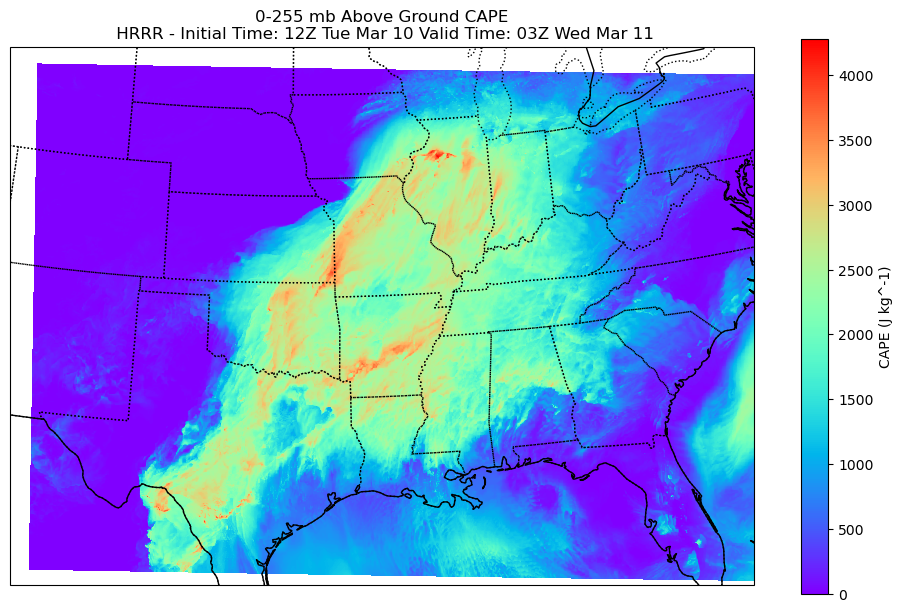

In [5]:
cape_5hr_rolling = ds_file["cape"].rolling(valid_time=5).max() #creating a cape_5hr_rolling so we can see the max amount of cape over a 5 hour period. 

fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, cape_5hr_rolling.isel(valid_time=15), cmap = 'rainbow', transform = dataproj) #creating the pcolor mesh with the valid_time of 15 with the color map of rainbow and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, label = 'CAPE (J kg^-1)', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size
ax.set_title(f"0-255 mb Above Ground CAPE\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #setting our title with the model type, initial time, valid time, and what it is plotting
plt.show() #plotting our map

We extract the vertical veloctity variable from the data file, again using the 5 hour rolling max time to account for short-range model biases. We call the map function, use the pcolormesh function to plot the 5 hour rolling time vertical velocity (setting minimum and maximum at 0 and 1.5 respectively), and generate a colorbar and title. In the title, we again use the extracted time of intialization and run time from the data file. We then display the plot. 

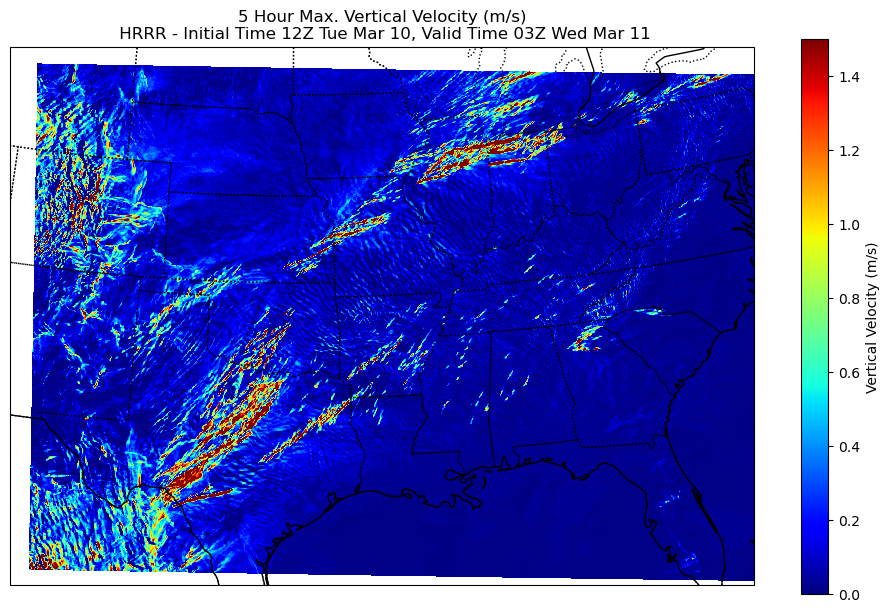

In [6]:
#Plot 2: Vertical Velocity worked on by Jonathan

wz_5hr_rolling = ds_file["wz"].rolling(valid_time=5).max() #Extracting the 5-hour max vertical velocity from the data file so it can be plotted

fig,ax=map() # Calling and printing the base map function created above

# Creating a colormesh plot of 5-hour max vertical velocity plotted on longitude and latitude, valid at 03Z
vert_velocity = ax.pcolormesh(ds_file.longitude, ds_file.latitude, wz_5hr_rolling.isel(valid_time=15), cmap = 'jet', vmin = 0, vmax = 1.5, transform=ccrs.PlateCarree())

cbar = plt.colorbar(vert_velocity, ax=ax, orientation='vertical', pad=0.05, shrink=0.8) # Creating a vertically oriented colorbar of 5-hour max vertical velocity
cbar.set_label('Vertical Velocity (m/s)') # Labeling colorbar with title and units

# Creating title containing information about content, initial time, and valid time of the plot
plt.title(f'5 Hour Max. Vertical Velocity (m/s)\n HRRR - Initial Time {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d}, Valid Time {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}')


plt.show() # Display the map

We extract the vertically integrated liquid variable from the data file, using the 5 hour rolling max time to account for short-range model biases. We call the map function, use the pcolormesh function to plot the 5 hour rolling time vertically integrated liquid (setting minimum and maximum at 0 and 15 respectively), and generate a colorbar and title. In the title, we again use the extracted time of intialization and run time from the data file. We then display the plot. 

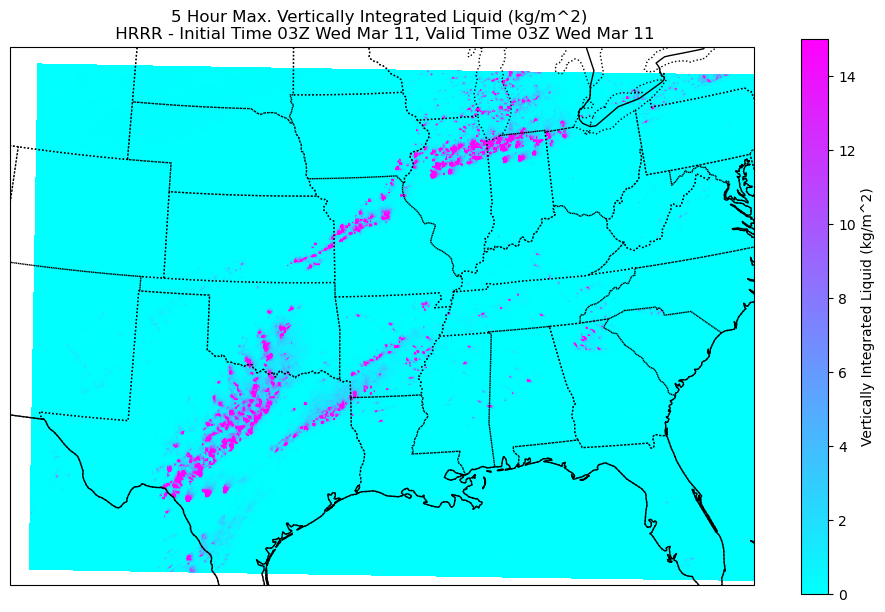

In [7]:
#Plot 3: Vertically Integrated Liquid worked on by Jonathan

veril_5hr_rolling = ds_file["veril"].rolling(valid_time=5).max() # Extracting the 5-hour max vertically integrated liquid from the data file so it can be plotted

fig,ax=map() #Calling and printing the base map function created above

# Creating a colormesh plot of 5-hour max vertically integrated liquid plotted on longitude and latitude, valid at 03Z
vert_int_liquid = ax.pcolormesh(ds_file.longitude, ds_file.latitude, veril_5hr_rolling.isel(valid_time=15), cmap = 'cool', vmin = 0, vmax = 15, transform=ccrs.PlateCarree())


cbar = plt.colorbar(vert_int_liquid, ax=ax, orientation='vertical', pad=0.05, shrink=0.8) # Creating a vertically oriented colorbar of 5-hour max vertically integrated liquid
cbar.set_label('Vertically Integrated Liquid (kg/m^2)') # Labeling colorbar with title and units

# Creating title containing information about content, initial time, and valid time of the plot
plt.title(f'5 Hour Max. Vertically Integrated Liquid (kg/m^2) \n HRRR - Initial Time {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}, Valid Time {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}')

# Display the map
plt.show()

We extract the reflectivity variable from the data file, using the 5 hour rolling max time to account for short-range model biases. We again call the map function, use the pcolormesh function to plot the 5 hour rolling time reflectivity, and generate a colorbar and title. In the title, we again use the extracted time of intialization and run time from the data file. Once more, we then display the plot. 

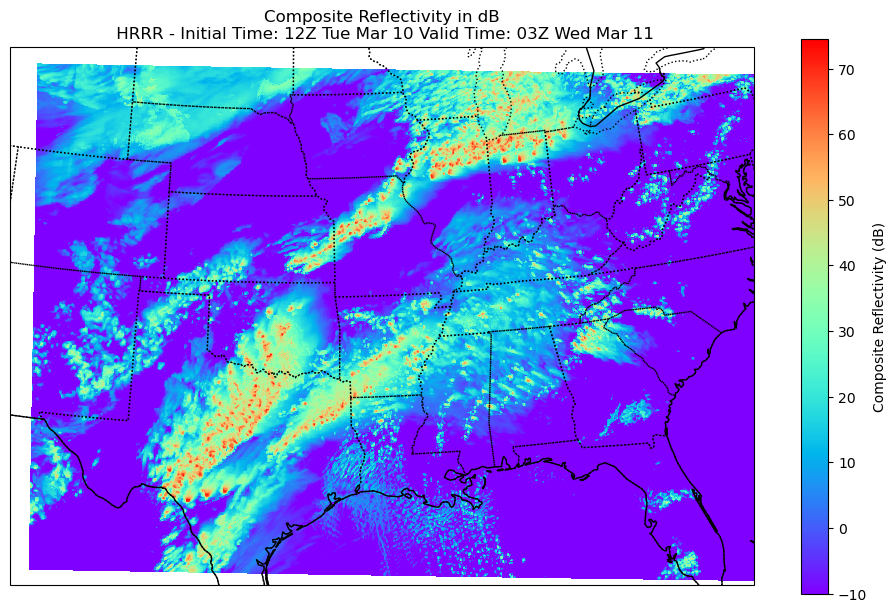

In [8]:
#Plot 4: Composite Reflectivity worked on by Myles
refc_5hr_rolling = ds_file["refc"].rolling(valid_time=5).max() #creating a composite reflectivity so we can see the max amount of composite reflectivity over a 5 hour period. 

fig,ax=map() #printing our the base map function we created above
pcolor2 = ax.pcolormesh(lon, lat, refc_5hr_rolling.isel(valid_time=15), cmap = 'rainbow', transform = dataproj) #creating the pcolor mesh with the valid_time of 15 with the color map of rainbow and adding longitude and latitude.
plt.colorbar(pcolor2, ax=ax, label = 'Composite Reflectivity (dB)', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size
ax.set_title(f"Composite Reflectivity in dB\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #setting our title with the model type, initial time, valid time, and what it is plotting
plt.show() #plotting our map

The last step here is to derive the vertically integrated liquid (VIL) density from the vertically integrated liquid. We had a bit of an issue with extracting the "cloudtop" variable, so we needed to rename an unknown variable to cloudtop in order to access it. Once we accessed it, we calculated VIL Density by taking the quotient of (VIL/cloudtop), and then extracting the 5 hour rolling max time and calling the map function. From there, we repeat previous steps. We again call the map function, use the pcolormesh function to plot the 5 hour rolling time reflectivity, and generate a colorbar and title. In the title, we again use the extracted time of intialization and run time from the data file. Finally, we then display the plot. 

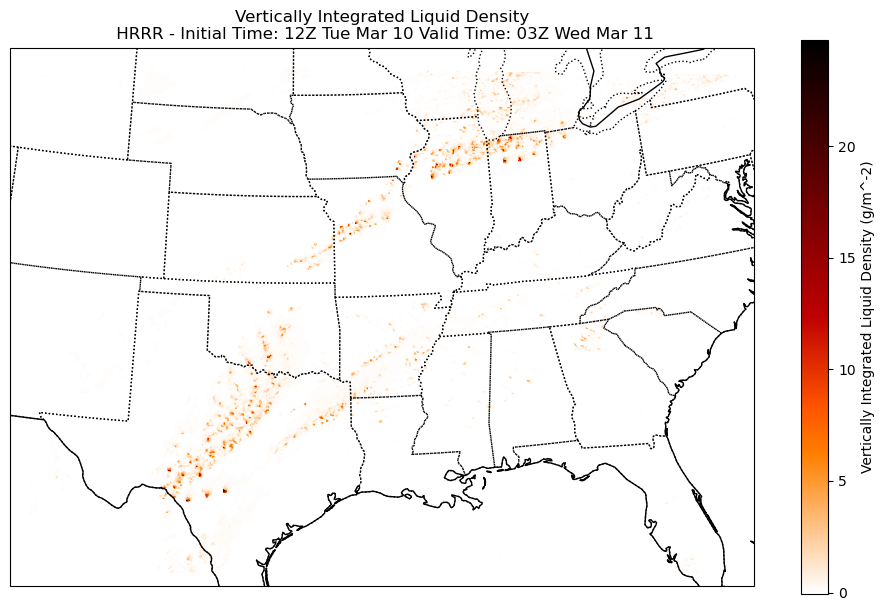

In [9]:
#Derived Parameter Plot worked on by Manuel

#derived products creation
ds_file = ds_file.rename({"unknown":"cloudtop"}) #renaming an unknown variable to cloudtop in order to workaround a naming issue with the cloudtop variable
vil_density =  (ds_file["veril"] /  ds_file["cloudtop"]) *1000 #calculating vertically integrated liquid density
vil_density_5hr_rolling = vil_density.rolling(valid_time=5).max()

fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, vil_density_5hr_rolling.isel(valid_time=15), cmap = 'gist_heat_r', transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of gist heat in reverse and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, label = 'Vertically Integrated Liquid Density (g/m^-2)', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size
ax.set_title(f"Vertically Integrated Liquid Density\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d} Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d}") #setting our title with the model type, initial time, valid time, and what it is plotting
plt.show() # Display the map
